In [37]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [38]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    
    sr: float
    bpb: float
    boundary_percent: float
    summary: str

In [39]:
def calculate_sr(state: BatsmanState):
    sr = (state['runs']/state['balls']) * 100
    return {'sr':sr}

In [40]:
def calculate_bpb(state: StateGraph):
    bpb = state['balls']/(state['fours'] + state['sixes'])

    return{'bpb': bpb} 

In [41]:
def calculate_percent(state: StateGraph):
    boundary_percent = (((state['fours']*4) + (state['sixes']*6))/ state['runs'])* 100

    return {'boundary_percent': boundary_percent}

In [42]:
def summary(state: StateGraph):
    summary = f"""
Strike_rate - {state['sr']} \n
BallsPerBoundary -{state['bpb']}\n
BoundaryPercent - {state['boundary_percent']}
"""
    return{'summary': summary}

In [43]:
Graph = StateGraph(BatsmanState)
Graph.add_node('calculate_sr' , calculate_sr)
Graph.add_node('calculate_bpb' , calculate_bpb)
Graph.add_node('calculate_percent', calculate_percent)
Graph.add_node('summary', summary)

Graph.add_edge(START,'calculate_sr')
Graph.add_edge(START,'calculate_bpb')
Graph.add_edge(START,'calculate_percent')

Graph.add_edge('calculate_sr', 'summary')
Graph.add_edge('calculate_bpb', 'summary')
Graph.add_edge('calculate_percent', 'summary')

Graph.add_edge('summary', END)

workflow = Graph.compile()

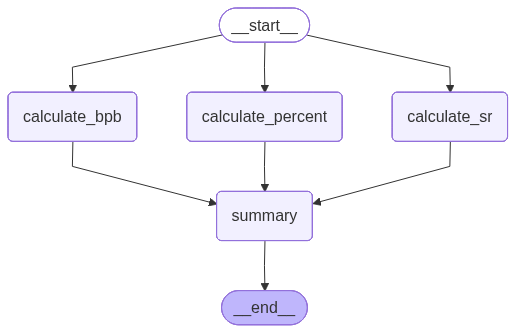

In [44]:
workflow

In [ ]:
initial_state = {
    'runs':120,
    'balls': 67,
    'fours': 8,
    'sixes': 5
}
workflow.invoke(initial_state)